# Experimentos com o Dataset MNIST
Este notebook tem como objetivo treinar a nossa implementação do Multi-Layer Perceptron (MLP) utilizando o dataset MNIST e gerar as métricas exigidas na rubrica.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
import sys
import os
sys.path.append(os.path.abspath('..'))
from mlp.network import MLP

# Carregar dados
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Transformar matriz 28x28 num vetor 1D de 784 posições e normalizar (0 a 1)
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1) / 255.0
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1) / 255.0

# Converter os labels para One-Hot Encoding
def to_one_hot(y, num_classes=10):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train = to_one_hot(y_train_raw)
y_test = to_one_hot(y_test_raw)

print("Dados prontos! Shape X_train:", X_train.shape)

I0000 00:00:1780968631.365534   32895 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780968631.430208   32895 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780968633.908650   32895 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dados prontos! Shape X_train: (60000, 784)


In [3]:
# Arquitetura: 784 pixels de entrada, 128 e 64 neurônios ocultos, 10 saídas
net = MLP([784, 128, 64, 10])

print("Iniciando o treinamento (isso pode levar alguns segundos por época)...")
history = net.train(X_train, y_train, epochs=20, batch_size=128, learning_rate=0.05)

Iniciando o treinamento (isso pode levar alguns segundos por época)...
Epoch 1/20 - Loss: 2.2999 - Acc: 0.1124
Epoch 10/20 - Loss: 0.1779 - Acc: 0.9519
Epoch 20/20 - Loss: 0.0826 - Acc: 0.9786


In [4]:
preds_test = net.forward(X_test)
preds_labels = np.argmax(preds_test, axis=1)

acc_test = np.mean(preds_labels == y_test_raw)
print(f"Acurácia no Teste: {acc_test * 100:.2f}%")

Acurácia no Teste: 96.72%


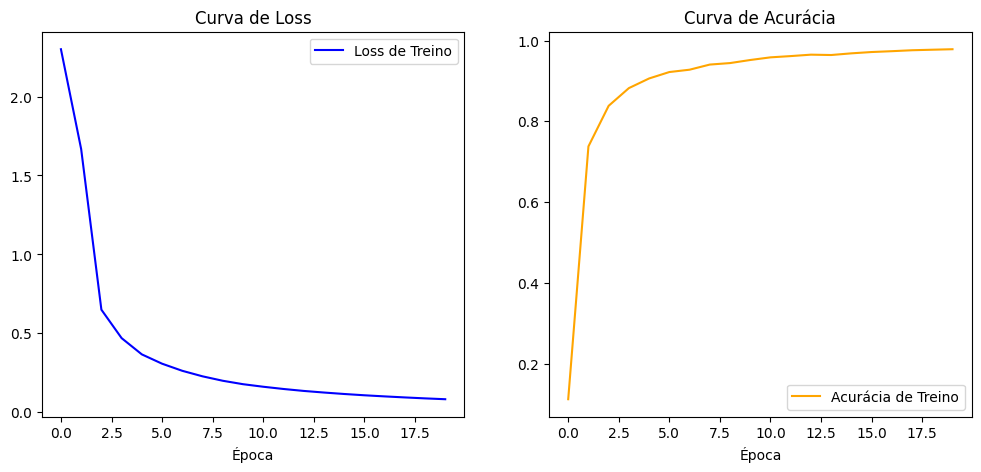

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss de Treino', color='blue')
plt.title('Curva de Loss')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Acurácia de Treino', color='orange')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.legend()
plt.show()

## Experimento 2: Rede Neural mais Rasa

Neste experimento, vamos comparar o desempenho treinando uma rede neural com apenas uma camada oculta ao invés de duas. Queremos validar se a complexidade extra do modelo principal era realmente necessária.

In [10]:
# Arquitetura mais simples: 784 pixels de entrada, APENAS 64 neurônios ocultos, 10 de saída
net_rasa = MLP([784, 64, 10])

print("Iniciando o treinamento da rede rasa...")
history_rasa = net_rasa.train(X_train, y_train, epochs=20, batch_size=128, learning_rate=0.05)

# Avaliação
preds_test_rasa = net_rasa.forward(X_test)
acc_test_rasa = np.mean(np.argmax(preds_test_rasa, axis=1) == y_test_raw)
print(f"Acurácia no Teste (Rede Rasa): {acc_test_rasa * 100:.2f}%")

Iniciando o treinamento da rede rasa...
Epoch 1/20 - Loss: 1.2015 - Acc: 0.8740
Epoch 10/20 - Loss: 0.1981 - Acc: 0.9460
Epoch 20/20 - Loss: 0.1250 - Acc: 0.9665
Acurácia no Teste (Rede Rasa): 96.17%
